In [1]:
from configs import avail_models, get_avail_splits
from models import norm_vals
from video_dataset import (
    get_wlasl_info,
    get_data_set,
    DataSetInfo,
    VideoDataset,
    InstanceDict
    )
import utils
import configs
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import video_transforms as vt
import torchvision.transforms.v2 as v2
from typing import (
    Tuple,
    Literal,
    cast,
    Any,
    Dict,
    List)
import torch
import torch.nn.functional as F
from testing import test_topk_clsrep
from models import get_model
import json

In [2]:
configs.set_seed()

## Setup

### Model

Available models:

In [3]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv1_B


Chosen model: 

In [4]:
model_name = av_models[6]
print(model_name)

MViTv2_S


Norm values: 

In [5]:
model_info = norm_vals(model_name)
print(model_info)

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


### Dataset

Available splits

In [6]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100
asl2000
asl300
asl1000


Chosen split, and set

In [7]:
split_name = av_splits[1]
print(split_name)

asl2000


Dataset info

In [8]:
test_info = get_wlasl_info(split_name, set_name="test")
print(test_info)


{'root': PosixPath('../data/WLASL/WLASL2000'), 'labels': PosixPath('preprocessed/labels/asl2000'), 'label_suff': 'fixed_frange_bboxes_len.json', 'set_name': 'test'}


Class list

In [9]:
class_list = configs.get_class_list()
print(len(class_list))

2000


#### Data Sets

one with centre crop and one with bounding box crop and resize


In [10]:
norm_dict = norm_vals(model_name)
print(model_info)
num_frames = 16
frame_size = 224
batch_size = 1

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


## Shared final transform

In [11]:
final_transform = v2.Compose(
    [
        v2.Lambda(vt._normalize_to_float),
        v2.Normalize(mean=norm_dict["mean"], std=norm_dict["std"]),
        v2.Lambda(vt._permute_time_channel),
        
    ]
)

## Centre Crop

Transform

In [12]:
cc_tranform = v2.Compose(
    [
        v2.CenterCrop(frame_size), final_transform
    ]
)

Dataset

In [13]:
cc_test_set = VideoDataset(
    set_info=test_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)

Dataloader

In [14]:
cc_loader = DataLoader(
    cc_test_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


## Bounding box Crop and resize

Transforms

In [15]:
# bbc_item_transform = lambda frames, item: vt.crop_frames(frames, item['bbox'])

def scale_and_pad(frames: torch.Tensor, size: int) -> torch.Tensor:
    """Scale the larger side to frame size, then pad boundaries. Assumes T C H W"""
    T, C, H, W = frames.shape

    # Scale so the LARGER side hits `size`, preserving aspect ratio
    if H >= W:
        new_H, new_W = size, round(W * size / H)
    else:
        new_H, new_W = round(H * size / W), size

    # torchvision resize handles T C H W directly
    resiz = v2.Resize( [new_H, new_W],
                    interpolation=v2.InterpolationMode.BICUBIC, antialias=True)

    # Distribute leftover pixels evenly; odd remainder goes to bottom/right
    pad_H = size - new_H
    pad_W = size - new_W
    top,  bottom = pad_H // 2, pad_H - pad_H // 2
    left, right  = pad_W // 2, pad_W - pad_W // 2

    return F.pad(resiz(frames), (left, right, top, bottom))  # F.pad: W then H



In [16]:
bbc_transform = v2.Compose([
    lambda x: scale_and_pad(x, frame_size), final_transform
])
# bbc_transform = v2.Compose([
#     final_transform
# ])

Dataset

In [17]:
bbc_test_set = VideoDataset(
    set_info=test_info,
    num_frames=num_frames,
    transforms=bbc_transform,   
    item_transforms=vt._crop_frames
)

In [18]:
bbc_loader = DataLoader(
    bbc_test_set,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [19]:
print(len(bbc_loader))
print(bbc_test_set.num_classes)

2879
2000


## Examine frames

In [20]:
iter_cc = iter(cc_loader)
iter_bbc = iter(bbc_loader)

In [21]:
sample_cc = next(iter_cc)
sample_bbc = next(iter_bbc)

In [22]:
cc_f = sample_cc['frames']
print(cc_f.shape)

bbc_f = sample_bbc['frames']
print(bbc_f.shape)

torch.Size([1, 3, 16, 224, 224])
torch.Size([1, 3, 16, 224, 224])


In [23]:
def prep_next2(sample: dict[str, int | torch.Tensor]) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'
    
    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3: 
        frames = frames.permute(1, 0, 2, 3) #swap T and C
    return frames, int(label_num.squeeze())

# Looking at what the machine sees 


In [24]:
figsize = (2,2)

## Centre Crop

frames: torch.Size([16, 3, 224, 224])
Class: book


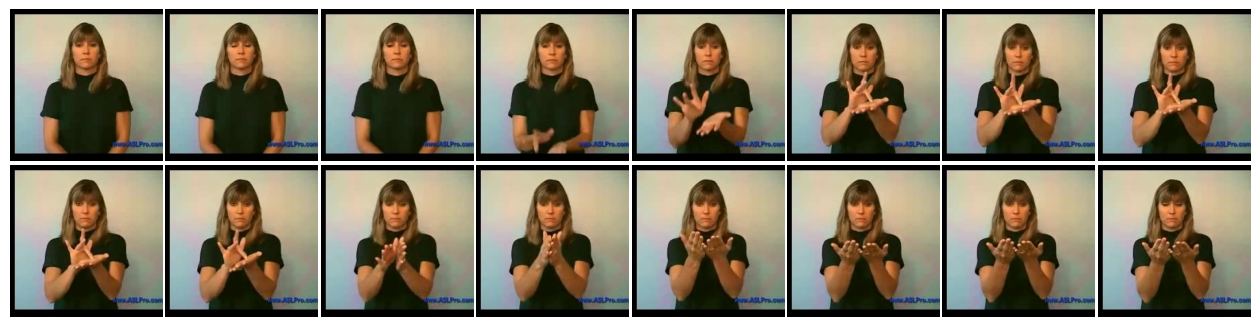

In [25]:
frames_cc, label_num = prep_next2(sample_cc)
print(f"frames: {frames_cc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_cc, num_frames, size=figsize)

## Bounding box crop

frames: torch.Size([16, 3, 224, 224])
Class: book


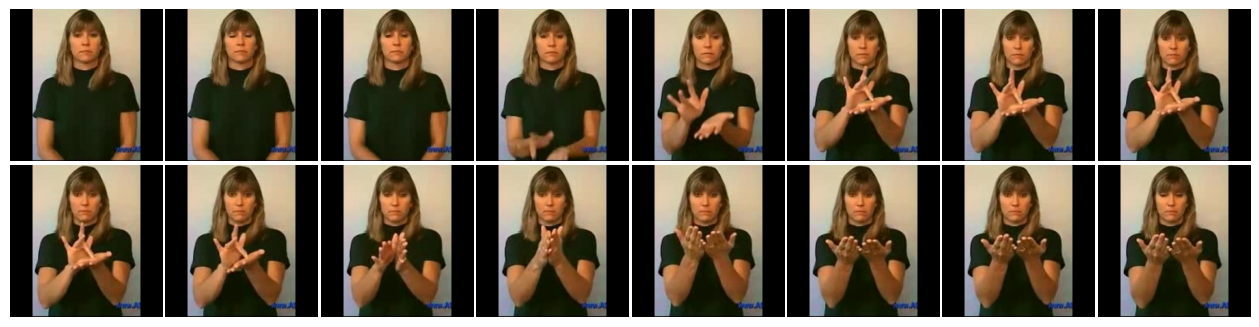

In [26]:
frames_bbc, label_num = prep_next2(sample_bbc)
print(f"frames: {frames_bbc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_bbc, num_frames, size=(2,2))

# Time to test

In [27]:

model = get_model(model_name, cc_test_set.num_classes, drop_p= 0.5)


/home/luke/miniconda3/envs/wlasl/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [28]:
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

In [29]:
exps_dict_path = Path('./results/wlasl_saicist.json')
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)



for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)

In [30]:
runs_dir = Path('./runs') / split_name
checkpoint_path = runs_dir / f'{model_name}_exp{exps_dict[split_name][model_name][0]}' / 'checkpoints' / 'best.pth'
checkpoint = torch.load(checkpoint_path)

/tmp/ipykernel_1231111/2543207289.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [31]:
model.load_state_dict(checkpoint)

<All keys matched successfully>

Centre crop

In [32]:

topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
		model=model,
		test_loader=cc_loader,
		verbose=False,
	)

Testing:   0%|          | 1/2879 [00:00<08:33,  5.61it/s]

Testing: 100%|██████████| 2879/2879 [03:00<00:00, 15.94it/s]

top-k average per class acc: 0.355025, 0.69265, 0.7828999999999999
top-k per instance acc: 0.38867662382771795, 0.7162209100382078, 0.7981938172976728
Averag Loss: 2.92


Bounding box crop

In [33]:

topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
		model=model,
		test_loader=bbc_loader,
		verbose=False,
	)

Testing: 100%|██████████| 2879/2879 [03:04<00:00, 15.62it/s]


top-k average per class acc: 0.35494166666666666, 0.6854, 0.7729166666666666
top-k per instance acc: 0.3869399096908649, 0.707884682181313, 0.7877735324765544
Averag Loss: 2.95


Conclusion:

no real impact of the bbox crop